In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, classification_report,
roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

from sklearn.model_selection import GridSearchCV

In [2]:
# Load Processed Data

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv')

In [3]:
y_train = y_train.values.ravel()    # Convert Target variable (y) from 1-column Table to the form of 1-D array (list)
y_test  = y_test.values.ravel()

In [4]:
print(X_train.shape)
print(y_train.shape)

(5634, 23)
(5634,)


##### “Feature scaling is not applied since the final selected model is Random Forest. Logistic Regression is used only for baseline comparison.”

### MODEL CREATION
### Baseline Model - Logistic Regression

In [5]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [6]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [7]:
print('Accuracy:', accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print('Classification Report:\n', classification_report(y_test, y_pred_log))

Accuracy: 0.8041163946061036
ROC-AUC: 0.8426334960861814
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



### Advanced Model - Random Forest

In [8]:
rf_model = RandomForestClassifier(random_state=42)

#### Random Forest (Default)

In [9]:
rf_model.fit(X_train, y_train)

y_pred_default = rf_model.predict(X_test)
y_prob_default = rf_model.predict_proba(X_test)[:, 1]

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_default))

Accuracy: 0.7927608232789212
ROC-AUC: 0.8259074117130383


#### Random Forest (Tuned)

In [11]:
parameters = {
    'n_estimators':[100,200],
    'criterion':['entropy','gini'],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

In [12]:
grid_search = GridSearchCV(
    estimator = rf_model,
    param_grid = parameters,
    cv = 5,
    scoring = 'roc_auc',
    n_jobs = -1,
    verbose = 1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

##### Used GridSearchCV with 5-fold cross-validation and ROC-AUC as the scoring metric to identify optimal hyperparameters.

In [13]:
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [14]:
y_pred_rf = best_model.predict(X_test)
y_prob_rf = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print('Classification Report:\n',classification_report(y_test, y_pred_rf))

Accuracy: 0.8062455642299503
ROC-AUC: 0.8462579761812499
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.51      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



##### ROC-AUC measures how well the model can distinguish between customers who churn and those who do not.
##### A higher ROC-AUC value indicates that the model is better at ranking churned customers with higher churn probabilities than non-churned customers.

##### In this project, the model achieved a ROC-AUC score of approximately 0.85, indicating strong predictive performance.

| Model                   | Accuracy  | ROC-AUC   |
| ----------------------- | --------- | --------- |
| Logistic Regression     | ~0.80     | ~0.84     |
| Random Forest (Default) | ~0.79     | ~0.83     |
| Random Forest (Tuned)   | **~0.81** | **~0.85** |


##### Random Forest was selected as the final model due to better performance and ability to handle non-linear relationships.

### Feature Importance

In [15]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X_train.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

imp_df.head(10)

,Feature,Importance
15,TotalCharges,0.193212
14,MonthlyCharges,0.180062
4,tenure,0.168290
16,InternetService_Fiber optic,0.044736
21,PaymentMethod_Electronic check,0.041651
19,Contract_Two year,0.032115
13,PaperlessBilling,0.029547
0,gender,0.028032
7,OnlineSecurity,0.023957
2,Partner,0.023469


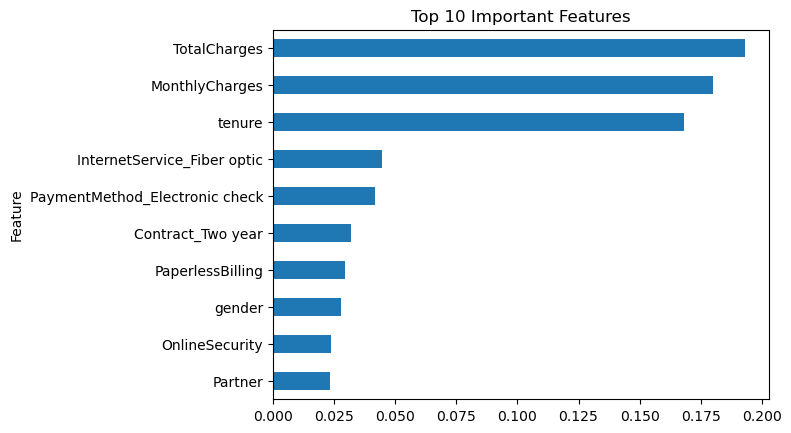

In [16]:
imp_df.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    legend=False
)
plt.gca().invert_yaxis()
plt.title('Top 10 Important Features')
plt.show()

##### Feature importance indicates how much each feature contributes to the model’s prediction.
##### Features with higher importance values play a greater role in identifying whether a customer will churn.
##### In this model, MonthlyCharges and TotalCharges (Tenure * MonthlyCharges) are the most important features. This shows that pricing and customer lifetime value play a key role in churn behavior. Customers with higher monthly bills and lower overall spending (new customers) are more likely to leave the service.

## Model Inference: Customer Churn Prediction

In [17]:
def predict_customer_churn(input_data):

    """
    input_data: dictionary with customer feature values (RAW, before encoding)
    returns: churn prediction text and probability
    """

    # convert input dictionary to DataFrame
    input_df = pd.DataFrame([input_data])

    # one-hot encode input (same as training)
    input_df = pd.get_dummies(input_df)

    # make input columns same as training columns
    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)

    # prediction
    prediction = rf_model.predict(input_df)[0]
    churn_prob = rf_model.predict_proba(input_df)[0][1]

    # readable output
    if prediction == 1:
        result = "Customer is likely to churn"
    else:
        result = "Customer is not likely to churn"

    return result, round(churn_prob * 100, 2)

In [18]:
customer_info = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 75.5,
    'TotalCharges': 850.0
}

predict_customer_churn(customer_info)

('Customer is not likely to churn', np.float64(34.0))

In [19]:
import pickle
import os

# Save the trained model ('pickle' converts the trained model into a file)
with open('../model/churn_model.pkl','wb') as file:
    pickle.dump(rf_model,file)

In [20]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [21]:
import pickle
import os

os.makedirs('../model', exist_ok=True)

with open('../model/feature_names.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)